In [ ]:
import os, numpy as np
from google.colab import drive
drive.mount('/content/drive')

BASE="/content/drive/MyDrive/corneal_ulcer_dataset"

train_images = np.load(os.path.join(BASE, "train_images.npy"))
train_ulcer  = np.load(os.path.join(BASE, "train_ulcer.npy"))
val_images   = np.load(os.path.join(BASE, "val_images.npy"))
val_ulcer    = np.load(os.path.join(BASE, "val_ulcer.npy"))
test_images  = np.load(os.path.join(BASE, "test_images.npy"))
test_ulcer   = np.load(os.path.join(BASE, "test_ulcer.npy"))

def ensure_mask_shape(m):
    if m.ndim == 3:  # (N,H,W)
        return np.expand_dims(m, -1)
    return m

train_ulcer = ensure_mask_shape(train_ulcer).astype(np.uint8)
val_ulcer   = ensure_mask_shape(val_ulcer).astype(np.uint8)
test_ulcer  = ensure_mask_shape(test_ulcer).astype(np.uint8)

print(train_images.shape, train_ulcer.shape)
print(val_images.shape, val_ulcer.shape)
print(test_images.shape, test_ulcer.shape)


Mounted at /content/drive
(247, 256, 256, 3) (247, 256, 256, 1)
(35, 256, 256, 3) (35, 256, 256, 1)
(72, 256, 256, 3) (72, 256, 256, 1)


In [ ]:
import tensorflow as tf
IMG_SIZE=256

@tf.function
def augment_pair(img, mask):

  # img:float32 [0,1], mask: uint8 {0,1}
  img = tf.cast(img, tf.float32)
  mask = tf.cast(mask, tf.float32)

  #Geometric aug
  #flips
  if tf.random.uniform(( ))>0.5:
      img  = tf.image.flip_left_right(img)
      mask = tf.image.flip_left_right(mask)
  if tf.random.uniform(()) > 0.5:
      img  = tf.image.flip_up_down(img)
      mask = tf.image.flip_up_down(mask)
  # (skipping rotation here to avoid extra deps; flips already help)

  #Photometric augmentation(IMAGE ONLY)
  img = tf.image.random_brightness(img, max_delta=0.08)
  img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
  img = tf.clip_by_value(img, 0.0, 1.0)

    # Keep mask binary
  mask = tf.where(mask > 0.5, 1.0, 0.0)

  return img, mask

def make_train_dataset(X, Y, batch=8):
  ds= tf.data.Dataset.from_tensor_slices((X, Y))
  ds = ds.shuffle(1000, reshuffle_each_iteration=True)
  ds =  ds.map(augment_pair, num_parallel_calls=tf.data.AUTOTUNE)
  ds =ds.batch(batch).prefetch(tf.data.AUTOTUNE)
  return ds

train_ds = make_train_dataset(train_images, train_ulcer, batch=8)
val_ds  = tf.data.Dataset.from_tensor_slices((val_images.astype(np.float32), val_ulcer.astype(np.float32))).batch(8)

print("train_ds, val_ds ready")


train_ds, val_ds ready


In [ ]:
import cv2, random
import numpy as np
import scipy.ndimage as ndi
from tqdm import tqdm

def clean_binary_mask(m):
  m = m.squeeze().astype(np.uint8)
  m = (m > 0).astype(np.uint8)

  # remove. tiny noise
  m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), iterations=1)
  # fill small holes
  m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8), iterations=1)

  return m

def elastic_transform_binary(mask, alpha=10, sigma=4):
  h, w = mask.shape
  dx = ndi.gaussian_filter((np.random.rand(h, w) * 2 - 1), sigma) * alpha
  dy = ndi.gaussian_filter((np.random.rand(h, w) * 2 - 1), sigma) * alpha

  x, y = np.meshgrid(np.arange(w), np.arange(h))
  map_x = (x + dx).astype(np.float32)
  map_y = (y + dy).astype(np.float32)

  out = cv2.remap(mask.astype(np.float32), map_x, map_y, interpolation=cv2.INTER_NEAREST, borderMode=cv2.BORDER_REFLECT)
  out = (out > 0.5).astype(np.uint8)
  return out

def perturb_mask(mask_1ch):
  m = clean_binary_mask(mask_1ch)

  # random affine
  angle = random.uniform(-12, 12)
  scale = random.uniform(0.95, 1.08)
  tx = random.uniform(-8, 8)
  ty = random.uniform(-8, 8)

  M = cv2.getRotationMatrix2D((m.shape[1]//2, m.shape[0]//2), angle, scale)
  M[0,2] += tx
  M[1,2] += ty

  m2 = cv2.warpAffine(m, M, (m.shape[1], m.shape[0]), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_REFLECT)
  m2 = (m2 > 0).astype(np.uint8)

  # elastic
  if random.random() < 0.7:
      m2 = elastic_transform_binary(m2, alpha=random.uniform(6,14), sigma=random.uniform(3,6))

  # slight dilate/erode (small)
  if random.random() < 0.5:
      m2 = cv2.dilate(m2, np.ones((3,3),np.uint8), iterations=1)
  else:
      m2 = cv2.erode(m2, np.ones((3,3),np.uint8), iterations=1)

  m2 = (m2 > 0).astype(np.uint8)
  return m2


In [ ]:
K = 4
new_masks = []
for m in tqdm(train_ulcer, total=len(train_ulcer)):
    base = clean_binary_mask(m)
    new_masks.append(base)
    for _ in range(K):
        new_masks.append(perturb_mask(base))

new_masks = np.array(new_masks, dtype=np.uint8)
new_masks = np.expand_dims(new_masks, -1)

print("perturbed masks v2:", new_masks.shape, new_masks.dtype, "unique:", np.unique(new_masks))
np.save(os.path.join(BASE, "perturbed_masks_v2.npy"), new_masks)


100%|██████████| 247/247 [00:05<00:00, 41.35it/s]


perturbed masks v2: (1235, 256, 256, 1) uint8 unique: [0 1]


In [ ]:
!pip -q install git+https://github.com/tensorflow/examples.git

import tensorflow as tf
from tensorflow_examples.models.pix2pix import pix2pix


  Preparing metadata (setup.py) ... done


In [ ]:
# x: mask (1ch) ->convert to 3ch
x_mask = train_ulcer.astype(np.float32)   # (N,256,256,1) in {0,1}
x_mask_3 = np.repeat(x_mask, 3, axis=-1) # (N,256,256,3)

# y: real image
y_img = train_images.astype(np.float32)  # (N,256,256,3) in [0,1]

# normalise BOTH to [-1,1]
x_mask_3 = x_mask_3 * 2.0 - 1.0
y_img    = y_img    * 2.0 - 1.0

ds = tf.data.Dataset.from_tensor_slices((x_mask_3, y_img))
ds = ds.shuffle(1000).batch(8).prefetch(tf.data.AUTOTUNE)

generator = pix2pix.unet_generator(output_channels=3, norm_type='batchnorm')
discriminator = pix2pix.discriminator(norm_type='batchnorm', target=True)


In [ ]:
loss_obj = tf.keras.losses.BinaryCrossentropy(from_logits=True)
def d_loss(real, fake):
    return loss_obj(tf.ones_like(real), real) + loss_obj(tf.zeros_like(fake), fake)

def g_loss(fake_disc, target, gen_out):
    l1 = tf.reduce_mean(tf.abs(target - gen_out))
    gan = loss_obj(tf.ones_like(fake_disc), fake_disc)
    return gan + 50*l1

g_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
d_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

@tf.function
def train_step(inp, tar):
    with tf.GradientTape() as gt, tf.GradientTape() as dt:
        gen_out = generator(inp, training=True)
        disc_real = discriminator([inp, tar], training=True)
        disc_fake = discriminator([inp, gen_out], training=True)

        gl = g_loss(disc_fake, tar, gen_out)
        dl = d_loss(disc_real, disc_fake)

    g_opt.apply_gradients(zip(gt.gradient(gl, generator.trainable_variables), generator.trainable_variables))
    d_opt.apply_gradients(zip(dt.gradient(dl, discriminator.trainable_variables), discriminator.trainable_variables))
    return gl, dl

EPOCHS=80
for e in range(EPOCHS):
    for inp, tar in ds:
        gl, dl = train_step(inp, tar)
    print(f"Epoch {e+1}/{EPOCHS} done | G {gl.numpy():.3f} D {dl.numpy():.3f}")

os.makedirs(os.path.join(BASE,"models"), exist_ok=True)
generator.save(os.path.join(BASE, "models/pix2pix_generator_v2.h5"))


Epoch 1/20 done | G 32.363 D 0.946
Epoch 2/20 done | G 29.129 D 0.323
Epoch 3/20 done | G 28.247 D 0.618
Epoch 4/20 done | G 27.546 D 1.000
Epoch 5/20 done | G 31.385 D 0.545
Epoch 6/20 done | G 31.686 D 0.354
Epoch 7/20 done | G 25.145 D 0.637
Epoch 8/20 done | G 23.029 D 0.784
Epoch 9/20 done | G 23.507 D 0.505
Epoch 10/20 done | G 24.096 D 0.796
Epoch 11/20 done | G 21.042 D 1.412
Epoch 12/20 done | G 20.622 D 0.678
Epoch 13/20 done | G 21.514 D 0.573
Epoch 14/20 done | G 19.718 D 0.864
Epoch 15/20 done | G 18.517 D 0.814
Epoch 16/20 done | G 19.671 D 0.835
Epoch 17/20 done | G 19.333 D 0.997
Epoch 18/20 done | G 17.819 D 0.794
Epoch 19/20 done | G 18.394 D 1.251


Epoch 20/20 done | G 17.228 D 1.205


In [ ]:
import os, cv2
from tqdm import tqdm

PERT_PATH = os.path.join(BASE, "perturbed_masks_v2.npy")
pert = np.load(PERT_PATH).astype(np.float32)  # (N,256,256,1) in {0,1}

syn_img_dir = os.path.join(BASE, "synthetic_v2/images")
syn_msk_dir = os.path.join(BASE, "synthetic_v2/masks")
os.makedirs(syn_img_dir, exist_ok=True)
os.makedirs(syn_msk_dir, exist_ok=True)

for i in tqdm(range(len(pert))):
    m = pert[i:i+1]  # (1,256,256,1)
    m3 = np.repeat(m, 3, axis=-1)             # (1,256,256,3)
    m3n = m3*2.0 - 1.0                      # [-1,1]

    gen = generator.predict(m3n, verbose=0)[0]  # [-1,1]
    gen = ((gen + 1.0)/2.0 * 255.0).clip(0,255).astype(np.uint8)

    # save image (png) + mask (png)
    cv2.imwrite(os.path.join(syn_img_dir, f"syn_{i:05d}.png"), cv2.cvtColor(gen, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(syn_msk_dir, f"syn_{i:05d}.png"), (pert[i].squeeze()*255).astype(np.uint8))

print("Saved synthetic pairs to:", syn_img_dir, syn_msk_dir)


100%|██████████| 1235/1235 [02:22<00:00,  8.66it/s]

Saved synthetic pairs to: /content/drive/MyDrive/corneal_ulcer_dataset/synthetic_v2/images /content/drive/MyDrive/corneal_ulcer_dataset/synthetic_v2/masks


In [ ]:
import os, cv2, random
import numpy as np
import matplotlib.pyplot as plt

syn_img_dir = os.path.join(BASE, "synthetic_v2/images")
syn_msk_dir = os.path.join(BASE, "synthetic_v2/masks")

def show_synth_pairs(n=8, seed=0):
    fns = sorted([f for f in os.listdir(syn_img_dir) if f.endswith(".png")])
    if len(fns) == 0:
        print("No images found in", syn_img_dir)
        return

    random.seed(seed)
    pick = random.sample(range(len(fns)), min(n, len(fns)))

    plt.figure(figsize=(12, 3*len(pick)))
    for r, idx in enumerate(pick):
        fn = fns[idx]
        img_path = os.path.join(syn_img_dir, fn)
        msk_path = os.path.join(syn_msk_dir, fn)  # same filename

        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        msk = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)

        # overlay (red mask)
        overlay = img.copy()
        mask_on = (msk > 0)
        overlay[mask_on] = (0.55*overlay[mask_on] + 0.45*np.array([255,0,0])).astype(np.uint8)

        plt.subplot(len(pick), 3, r*3+1)
        plt.title("Synthetic image")
        plt.imshow(img)
        plt.axis("off")

        plt.subplot(len(pick), 3, r*3+2)
        plt.title("Mask")
        plt.imshow(msk, cmap="gray")
        plt.axis("off")

        plt.subplot(len(pick), 3, r*3+3)
        plt.title("Overlay")
        plt.imshow(overlay)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_synth_pairs(n=10, seed=42)


Output hidden; open in https://colab.research.google.com to view.

up to here I trained pix2pix with ulcer mask → image only. That’s under-conditioned: the GAN doesn’t know where the cornea/iris/specular highlights should be, so it invents textures.


In [ ]:
import os, numpy as np, cv2, random
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm

BASE="/content/drive/MyDrive/corneal_ulcer_dataset"

train_images = np.load(os.path.join(BASE, "train_images.npy")).astype(np.float32)  # [0,1]
train_ulcer  = np.load(os.path.join(BASE, "train_ulcer.npy")).astype(np.uint8)
train_cornea = np.load(os.path.join(BASE, "train_cornea.npy")).astype(np.uint8)

def ensure_1ch(m):
    if m.ndim == 3:
        return np.expand_dims(m, -1)
    return m

train_ulcer  = ensure_1ch(train_ulcer)
train_cornea = ensure_1ch(train_cornea)

print("train_images:", train_images.shape, train_images.min(), train_images.max())
print("train_ulcer:", train_ulcer.shape, np.unique(train_ulcer))
print("train_cornea:", train_cornea.shape, np.unique(train_cornea))


train_images: (247, 256, 256, 3) 0.0 1.0
train_ulcer: (247, 256, 256, 1) [0 1]
train_cornea: (247, 256, 256, 1) [0 1]


In [ ]:
def mask_edges(binary_1ch):
  m = binary_1ch.squeeze().astype(np.uint8)
  e = cv2.Canny(m*255, 50, 150)  # edges in {0,255}
  e = (e > 0).astype(np.float32)
  return e[..., None]  # (H,W,1)

# Build conditioning inputs (N,256,256,3) in [0,1]
X_cond = []
for i in range(len(train_ulcer)):
    c = train_cornea[i].astype(np.float32)  # (H,W,1)
    u = train_ulcer[i].astype(np.float32)   # (H,W,1)
    e = mask_edges(train_ulcer[i])          # (H,W,1)
    x = np.concatenate([c, u, e], axis=-1)  # (H,W,3)
    X_cond.append(x)

X_cond = np.stack(X_cond, axis=0).astype(np.float32)
Y_img  = train_images.astype(np.float32)

print("X_cond:", X_cond.shape, X_cond.min(), X_cond.max())
print("Y_img:", Y_img.shape, Y_img.min(), Y_img.max())

# Normalise to [-1,1] for pix2pix
X_cond_n = X_cond * 2.0 - 1.0
Y_img_n  = Y_img  * 2.0 - 1.0


X_cond: (247, 256, 256, 3) 0.0 1.0
Y_img: (247, 256, 256, 3) 0.0 1.0


In [ ]:
!pip -q install git+https://github.com/tensorflow/examples.git
from tensorflow_examples.models.pix2pix import pix2pix

BATCH=8
ds = tf.data.Dataset.from_tensor_slices((X_cond_n, Y_img_n))
ds = ds.shuffle(1000, reshuffle_each_iteration=True).batch(BATCH).prefetch(tf.data.AUTOTUNE)

generator_v3 = pix2pix.unet_generator(output_channels=3, norm_type='batchnorm')
discriminator_v3 = pix2pix.discriminator(norm_type='batchnorm', target=True)

loss_obj = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def d_loss(real, fake):
    return loss_obj(tf.ones_like(real), real) + loss_obj(tf.zeros_like(fake), fake)

def g_loss(fake_disc, target, gen_out, L1_WEIGHT=100.0):
    l1 = tf.reduce_mean(tf.abs(target - gen_out))
    gan = loss_obj(tf.ones_like(fake_disc), fake_disc)
    return gan + L1_WEIGHT*l1

g_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
d_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

@tf.function
def train_step(inp, tar):
    with tf.GradientTape() as gt, tf.GradientTape() as dt:
        gen_out = generator_v3(inp, training=True)
        disc_real = discriminator_v3([inp, tar], training=True)
        disc_fake = discriminator_v3([inp, gen_out], training=True)

        gl = g_loss(disc_fake, tar, gen_out, L1_WEIGHT=100.0)
        dl = d_loss(disc_real, disc_fake)

    g_opt.apply_gradients(zip(gt.gradient(gl, generator_v3.trainable_variables), generator_v3.trainable_variables))
    d_opt.apply_gradients(zip(dt.gradient(dl, discriminator_v3.trainable_variables), discriminator_v3.trainable_variables))
    return gl, dl, gen_out


  Preparing metadata (setup.py) ... done


In [ ]:
def show_gan_samples(epoch, n=3):
    idxs = np.random.choice(len(X_cond_n), size=n, replace=False)
    preds = generator_v3(X_cond_n[idxs], training=False).numpy()  # [-1,1]
    preds = ((preds + 1.0)/2.0).clip(0,1)

    plt.figure(figsize=(10, 3*n))
    for r, idx in enumerate(idxs):
        cond = ((X_cond_n[idx] + 1.0)/2.0)  # back to [0,1]
        real = train_images[idx]
        fake = preds[r]

        plt.subplot(n, 3, r*3+1); plt.title("Condition (C,U,edge)"); plt.imshow(cond); plt.axis("off")
        plt.subplot(n, 3, r*3+2); plt.title("Real"); plt.imshow(real); plt.axis("off")
        plt.subplot(n, 3, r*3+3); plt.title("Fake"); plt.imshow(fake); plt.axis("off")
    plt.tight_layout()
    plt.show()

EPOCHS=60
for e in range(EPOCHS):
    for inp, tar in ds:
        gl, dl, _ = train_step(inp, tar)
    if (e+1) % 5 == 0:
        print(f"Epoch {e+1}/{EPOCHS} | G {gl.numpy():.3f} D {dl.numpy():.3f}")
        show_gan_samples(e+1, n=3)

os.makedirs(os.path.join(BASE,"models"), exist_ok=True)
generator_v3.save(os.path.join(BASE, "models/pix2pix_generator_v3.keras"))
print("Saved generator_v3")


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
PERT_PATH = os.path.join(BASE, "perturbed_masks_v2.npy")
pert_ulcer = np.load(PERT_PATH).astype(np.uint8)  # (N,256,256,1) in {0,1}

# We need a cornea mask per perturbed mask.
# Your v2 generation created K perturbs per original in order.
# You used K=4 and also included base, so per original: (1+K) masks.
K = 4
per_original = 1 + K
assert len(pert_ulcer) == len(train_cornea) * per_original

# Expand cornea masks to match perturbed masks
cornea_rep = np.repeat(train_cornea, repeats=per_original, axis=0).astype(np.uint8)
print("pert_ulcer:", pert_ulcer.shape, "cornea_rep:", cornea_rep.shape)

# Save these as your v3 conditioning masks (paired)
np.save(os.path.join(BASE, "perturbed_ulcer_v3.npy"), pert_ulcer)
np.save(os.path.join(BASE, "perturbed_cornea_v3.npy"), cornea_rep)
print("Saved perturbed_ulcer_v3 and perturbed_cornea_v3")


In [ ]:
ulcer_v3 = np.load(os.path.join(BASE, "perturbed_ulcer_v3.npy")).astype(np.float32)
cornea_v3 = np.load(os.path.join(BASE, "perturbed_cornea_v3.npy")).astype(np.float32)

syn_img_dir = os.path.join(BASE, "synthetic_v3/images")
syn_msk_dir = os.path.join(BASE, "synthetic_v3/ulcer_masks")
syn_cor_dir = os.path.join(BASE, "synthetic_v3/cornea_masks")
os.makedirs(syn_img_dir, exist_ok=True)
os.makedirs(syn_msk_dir, exist_ok=True)
os.makedirs(syn_cor_dir, exist_ok=True)

def make_cond(cornea_1ch, ulcer_1ch):
    e = mask_edges(ulcer_1ch.astype(np.uint8))
    x = np.concatenate([cornea_1ch, ulcer_1ch, e], axis=-1).astype(np.float32)  # [0,1]
    return x

for i in tqdm(range(len(ulcer_v3))):
    u = ulcer_v3[i:i+1]  # (1,256,256,1) 0/1
    c = cornea_v3[i:i+1] # (1,256,256,1) 0/1
    cond = make_cond(c[0], u[0])[None, ...]  # (1,256,256,3)
    cond_n = cond*2.0 - 1.0

    gen = generator_v3.predict(cond_n, verbose=0)[0]  # [-1,1]
    gen = ((gen + 1.0)/2.0 * 255.0).clip(0,255).astype(np.uint8)

    cv2.imwrite(os.path.join(syn_img_dir, f"syn_{i:05d}.png"), cv2.cvtColor(gen, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(syn_msk_dir, f"syn_{i:05d}.png"), (u[0].squeeze()*255).astype(np.uint8))
    cv2.imwrite(os.path.join(syn_cor_dir, f"syn_{i:05d}.png"), (c[0].squeeze()*255).astype(np.uint8))

print("Saved synthetic_v3 to:", syn_img_dir)


In [ ]:
import matplotlib.pyplot as plt

def show_pairs_v3(n=8, seed=0):
    fns = sorted([f for f in os.listdir(syn_img_dir) if f.endswith(".png")])
    random.seed(seed)
    pick = random.sample(range(len(fns)), min(n, len(fns)))

    plt.figure(figsize=(12, 3*len(pick)))
    for r, idx in enumerate(pick):
        fn = fns[idx]
        img = cv2.cvtColor(cv2.imread(os.path.join(syn_img_dir, fn)), cv2.COLOR_BGR2RGB)
        msk = cv2.imread(os.path.join(syn_msk_dir, fn), cv2.IMREAD_GRAYSCALE)

        overlay = img.copy()
        overlay[msk > 0] = (0.55*overlay[msk > 0] + 0.45*np.array([255,0,0])).astype(np.uint8)

        plt.subplot(len(pick), 3, r*3+1); plt.title("Synthetic"); plt.imshow(img); plt.axis("off")
        plt.subplot(len(pick), 3, r*3+2); plt.title("Mask"); plt.imshow(msk, cmap="gray"); plt.axis("off")
        plt.subplot(len(pick), 3, r*3+3); plt.title("Overlay"); plt.imshow(overlay); plt.axis("off")

    plt.tight_layout(); plt.show()

show_pairs_v3(n=10, seed=42)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, numpy as np, cv2
BASE="/content/drive/MyDrive/corneal_ulcer_dataset"
print("BASE exists:", os.path.exists(BASE))


Mounted at /content/drive
BASE exists: True


In [ ]:
import tensorflow as tf
generator_v3 = tf.keras.models.load_model(
    os.path.join(BASE, "models/pix2pix_generator_v3.keras"),
    compile=False
)
print("Loaded generator_v3")


Loaded generator_v3


In [ ]:
import os, numpy as np

BASE="/content/drive/MyDrive/corneal_ulcer_dataset"

# Load what exists
pert_ulcer = np.load(os.path.join(BASE, "perturbed_masks_v2.npy")).astype(np.uint8)
train_cornea = np.load(os.path.join(BASE, "train_cornea.npy")).astype(np.uint8)

# Ensure shape (N,H,W,1)
if train_cornea.ndim == 3:
    train_cornea = np.expand_dims(train_cornea, -1)

# IMPORTANT: this must match the created perturbed_masks_v2
K = 4
per_original = 1 + K      # base + K perturbations

assert len(pert_ulcer) == len(train_cornea) * per_original, \
    "Mismatch: perturbed masks count does not match cornea replication logic"

# Repeat cornea masks to align with perturbed ulcers
cornea_rep = np.repeat(train_cornea, repeats=per_original, axis=0)

# Save v3 files
np.save(os.path.join(BASE, "perturbed_ulcer_v3.npy"), pert_ulcer)
np.save(os.path.join(BASE, "perturbed_cornea_v3.npy"), cornea_rep)

print("Saved:")
print(" perturbed_ulcer_v3.npy :", pert_ulcer.shape)
print(" perturbed_cornea_v3.npy:", cornea_rep.shape)


Saved:
 perturbed_ulcer_v3.npy : (1235, 256, 256, 1)
 perturbed_cornea_v3.npy: (1235, 256, 256, 1)


In [ ]:
ulcer_v3  = np.load(os.path.join(BASE, "perturbed_ulcer_v3.npy")).astype(np.float32)
cornea_v3 = np.load(os.path.join(BASE, "perturbed_cornea_v3.npy")).astype(np.float32)

print("ulcer_v3:", ulcer_v3.shape, ulcer_v3.min(), ulcer_v3.max())
print("cornea_v3:", cornea_v3.shape, cornea_v3.min(), cornea_v3.max())


ulcer_v3: (1235, 256, 256, 1) 0.0 1.0
cornea_v3: (1235, 256, 256, 1) 0.0 1.0


In [ ]:
def mask_edges(binary_1ch):
    m = binary_1ch.squeeze().astype(np.uint8)
    e = cv2.Canny(m*255, 50, 150)
    e = (e > 0).astype(np.float32)
    return e[..., None]

def make_cond(cornea_1ch, ulcer_1ch):
    e = mask_edges(ulcer_1ch.astype(np.uint8))
    x = np.concatenate([cornea_1ch, ulcer_1ch, e], axis=-1).astype(np.float32)  # [0,1]
    return x


In [ ]:
import os, cv2
from tqdm import tqdm
import numpy as np

BASE="/content/drive/MyDrive/corneal_ulcer_dataset"

syn_img_dir_v4 = os.path.join(BASE, "synthetic_v4/images")
syn_msk_dir_v4 = os.path.join(BASE, "synthetic_v4/ulcer_masks")
syn_cor_dir_v4 = os.path.join(BASE, "synthetic_v4/cornea_masks")

os.makedirs(syn_img_dir_v4, exist_ok=True)
os.makedirs(syn_msk_dir_v4, exist_ok=True)
os.makedirs(syn_cor_dir_v4, exist_ok=True)

print("Will save to:", syn_img_dir_v4)


Will save to: /content/drive/MyDrive/corneal_ulcer_dataset/synthetic_v4/images


In [ ]:
from tqdm import tqdm
import cv2
import numpy as np

M = 4   # number of variants per mask (3–5 is good)
idx = 0

for i in tqdm(range(len(ulcer_v3))):
    u = ulcer_v3[i:i+1]  # (1,256,256,1)
    c = cornea_v3[i:i+1] # (1,256,256,1)

    # build conditioning
    cond = make_cond(c[0], u[0])[None, ...]   # (1,256,256,3) in [0,1]
    cond_n = cond * 2.0 - 1.0                 # [-1,1]

    for j in range(M):
        # IMPORTANT: training=True enables dropout → diversity
        gen = generator_v3(cond_n, training=True).numpy()[0]  # [-1,1]
        gen = ((gen + 1.0)/2.0 * 255.0).clip(0,255).astype(np.uint8)

        fn = f"syn_{idx:06d}.png"
        cv2.imwrite(os.path.join(syn_img_dir_v4, fn),
                    cv2.cvtColor(gen, cv2.COLOR_RGB2BGR))
        cv2.imwrite(os.path.join(syn_msk_dir_v4, fn),
                    (u[0].squeeze()*255).astype(np.uint8))
        cv2.imwrite(os.path.join(syn_cor_dir_v4, fn),
                    (c[0].squeeze()*255).astype(np.uint8))

        idx += 1

print("Saved", idx, "diverse synthetic images (v4).")


  0%|          | 0/1235 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_19']
Received: inputs=Tensor(shape=(1, 256, 256, 3))
  warnings.warn(msg)
100%|██████████| 1235/1235 [10:12<00:00,  2.02it/s]

Saved 4940 diverse synthetic images (v4).


In [ ]:
import matplotlib.pyplot as plt
import random

def show_pairs(folder_img, folder_msk, n=10, seed=42):
    fns = sorted([f for f in os.listdir(folder_img) if f.endswith(".png")])
    random.seed(seed)
    pick = random.sample(range(len(fns)), min(n, len(fns)))

    plt.figure(figsize=(12, 3*len(pick)))
    for r, idx in enumerate(pick):
        fn = fns[idx]
        img = cv2.cvtColor(cv2.imread(os.path.join(folder_img, fn)), cv2.COLOR_BGR2RGB)
        msk = cv2.imread(os.path.join(folder_msk, fn), cv2.IMREAD_GRAYSCALE)

        overlay = img.copy()
        overlay[msk > 0] = (0.55*overlay[msk > 0] + 0.45*np.array([255,0,0])).astype(np.uint8)

        plt.subplot(len(pick), 3, r*3+1); plt.title("Synthetic v4"); plt.imshow(img); plt.axis("off")
        plt.subplot(len(pick), 3, r*3+2); plt.title("Mask"); plt.imshow(msk, cmap="gray"); plt.axis("off")
        plt.subplot(len(pick), 3, r*3+3); plt.title("Overlay"); plt.imshow(overlay); plt.axis("off")

    plt.tight_layout(); plt.show()

show_pairs(syn_img_dir_v4, syn_msk_dir_v4, n=10, seed=42)


Output hidden; open in https://colab.research.google.com to view.

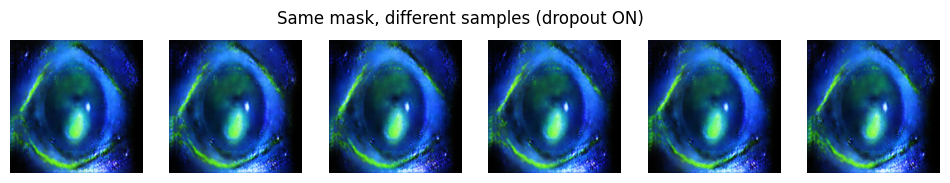

In [ ]:
def show_same_mask_variants(mask_index=0, M_show=6):
    u = ulcer_v3[mask_index:mask_index+1]
    c = cornea_v3[mask_index:mask_index+1]

    cond = make_cond(c[0], u[0])[None, ...]
    cond_n = cond*2.0 - 1.0

    plt.figure(figsize=(12,2))
    for j in range(M_show):
        gen = generator_v3(cond_n, training=True).numpy()[0]
        gen = ((gen + 1.0)/2.0).clip(0,1)
        plt.subplot(1, M_show, j+1)
        plt.imshow(gen)
        plt.axis("off")
    plt.suptitle("Same mask, different samples (dropout ON)")
    plt.show()

show_same_mask_variants(mask_index=0, M_show=6)


still no diversity showing


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, numpy as np, cv2
BASE="/content/drive/MyDrive/corneal_ulcer_dataset"

train_images = np.load(os.path.join(BASE, "train_images.npy")).astype(np.float32)
train_ulcer  = np.load(os.path.join(BASE, "train_ulcer.npy")).astype(np.float32)
train_cornea = np.load(os.path.join(BASE, "train_cornea.npy")).astype(np.float32)

if train_ulcer.ndim == 3: train_ulcer = train_ulcer[...,None]
if train_cornea.ndim == 3: train_cornea = train_cornea[...,None]

print(train_images.shape, train_ulcer.shape, train_cornea.shape)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(247, 256, 256, 3) (247, 256, 256, 1) (247, 256, 256, 1)


In [ ]:
def mask_edges(binary_1ch):
    m = binary_1ch.squeeze().astype(np.uint8)
    e = cv2.Canny(m*255, 50, 150)
    e = (e > 0).astype(np.float32)
    return e[..., None]

def make_cond_with_noise(cornea_1ch, ulcer_1ch, noise_std=0.15):
    e = mask_edges(ulcer_1ch.astype(np.uint8))
    noise = np.random.normal(0, noise_std, size=ulcer_1ch.shape).astype(np.float32)
    noise = np.clip(noise, -1, 1)
    return np.concatenate([cornea_1ch, ulcer_1ch, e, noise], axis=-1).astype(np.float32)


In [ ]:
X_cond4 = np.stack([
    make_cond_with_noise(train_cornea[i], train_ulcer[i], noise_std=0.15)
    for i in range(len(train_ulcer))
]).astype(np.float32)

Y_img = train_images.astype(np.float32)

X_cond4_n = X_cond4*2.0 - 1.0
Y_img_n   = Y_img*2.0 - 1.0

print("X_cond4_n:", X_cond4_n.shape, "Y_img_n:", Y_img_n.shape)


X_cond4_n: (247, 256, 256, 4) Y_img_n: (247, 256, 256, 3)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# --- Generator: U-Net with UpSampling2D (avoids checkerboard) ---
def down_block(x, f):
    x = layers.Conv2D(f, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    return x

def up_block(x, skip, f):
    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(f, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Concatenate()([x, skip])
    return x

def build_generator(input_channels=4, base=64):
    inp = layers.Input(shape=(256,256,input_channels))

    d1 = down_block(inp, base)        # 128
    d2 = down_block(d1, base*2)       # 64
    d3 = down_block(d2, base*4)       # 32
    d4 = down_block(d3, base*8)       # 16
    d5 = down_block(d4, base*8)       # 8

    b  = layers.Conv2D(base*8, 3, padding="same", activation="relu")(d5)

    u1 = up_block(b,  d4, base*8)     # 16
    u2 = up_block(u1, d3, base*4)     # 32
    u3 = up_block(u2, d2, base*2)     # 64
    u4 = up_block(u3, d1, base)       # 128

    u5 = layers.UpSampling2D()(u4)    # 256
    out = layers.Conv2D(3, 3, padding="same", activation="tanh")(u5)  # [-1,1]

    return Model(inp, out, name="G_mask_cornea_edge_noise")

# --- Discriminator: PatchGAN ---
def build_discriminator(input_channels=4, base=64):
    inp = layers.Input(shape=(256,256,input_channels))  # condition (4ch)
    tar = layers.Input(shape=(256,256,3))               # image (3ch)

    x = layers.Concatenate()([inp, tar])                # 7 channels

    x = layers.Conv2D(base, 4, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(base*2, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(base*4, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(base*8, 4, strides=1, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    out = layers.Conv2D(1, 4, strides=1, padding="same")(x)  # logits
    return Model([inp, tar], out, name="D_patchgan")

generator_v4 = build_generator(input_channels=4, base=64)
discriminator_v4 = build_discriminator(input_channels=4, base=64)

print(generator_v4.input_shape, generator_v4.output_shape)
print(discriminator_v4.input_shape)


(None, 256, 256, 4) (None, 256, 256, 3)
[(None, 256, 256, 4), (None, 256, 256, 3)]


In [ ]:
loss_obj = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def d_loss(real_logits, fake_logits):
    return loss_obj(tf.ones_like(real_logits), real_logits) + loss_obj(tf.zeros_like(fake_logits), fake_logits)

def g_loss(fake_logits, target, gen_out, L1_WEIGHT=30.0):
    gan = loss_obj(tf.ones_like(fake_logits), fake_logits)
    l1  = tf.reduce_mean(tf.abs(target - gen_out))
    return gan + L1_WEIGHT*l1

g_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
d_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

@tf.function
def train_step_v4(inp, tar):
    with tf.GradientTape() as gt, tf.GradientTape() as dt:
        gen_out = generator_v4(inp, training=True)
        real_logits = discriminator_v4([inp, tar], training=True)
        fake_logits = discriminator_v4([inp, gen_out], training=True)

        gl = g_loss(fake_logits, tar, gen_out, L1_WEIGHT=30.0)
        dl = d_loss(real_logits, fake_logits)

    g_opt.apply_gradients(zip(gt.gradient(gl, generator_v4.trainable_variables), generator_v4.trainable_variables))
    d_opt.apply_gradients(zip(dt.gradient(dl, discriminator_v4.trainable_variables), discriminator_v4.trainable_variables))
    return gl, dl

EPOCHS = 35
for e in range(EPOCHS):
    for inp, tar in ds4:
        gl, dl = train_step_v4(inp, tar)
    if (e+1) % 5 == 0:
        print(f"Epoch {e+1}/{EPOCHS} | G {gl.numpy():.3f} D {dl.numpy():.3f}")

os.makedirs(os.path.join(BASE,"models"), exist_ok=True)
generator_v4.save(os.path.join(BASE, "models/pix2pix_generator_v4_noise.keras"))
print("Saved generator_v4_noise")


Epoch 5/35 | G 10.532 D 0.363
Epoch 10/35 | G 10.871 D 0.092
Epoch 15/35 | G 8.739 D 1.952
Epoch 20/35 | G 6.147 D 1.004
Epoch 25/35 | G 5.950 D 1.128
Epoch 30/35 | G 5.279 D 1.073
Epoch 35/35 | G 5.517 D 1.225
Saved generator_v4_noise


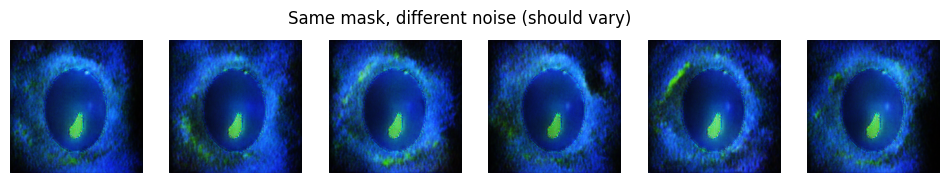

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def preview_same_mask(k=6, idx=0, noise_std=0.15):
    u = train_ulcer[idx].astype(np.float32)
    c = train_cornea[idx].astype(np.float32)

    plt.figure(figsize=(12,2))
    for i in range(k):
        cond = make_cond_with_noise(c, u, noise_std=noise_std)[None, ...]  # (1,256,256,4)
        cond_n = cond*2.0 - 1.0
        gen = generator_v4(cond_n, training=False).numpy()[0]              # [-1,1]
        gen = ((gen + 1.0)/2.0).clip(0,1)
        plt.subplot(1,k,i+1)
        plt.imshow(gen)
        plt.axis("off")
    plt.suptitle("Same mask, different noise (should vary)")
    plt.show()

preview_same_mask(k=6, idx=0, noise_std=0.15)


Version	What changed
v2	ulcer-mask → image (bad, under-conditioned)
v3	cornea + ulcer + edge → image
v4	cornea + ulcer + edge + noise → image (diverse)

In [ ]:
import os, numpy as np, cv2
from tqdm import tqdm

BASE="/content/drive/MyDrive/corneal_ulcer_dataset"

pert_ulcer = np.load(os.path.join(BASE, "perturbed_masks_v2.npy")).astype(np.float32)  # (1235,256,256,1)
train_cornea_u8 = np.load(os.path.join(BASE, "train_cornea.npy")).astype(np.uint8)
if train_cornea_u8.ndim == 3:
    train_cornea_u8 = train_cornea_u8[..., None]

K = 4
per_original = 1 + K
cornea_rep = np.repeat(train_cornea_u8, repeats=per_original, axis=0).astype(np.float32)

assert len(pert_ulcer) == len(cornea_rep)

ulcer_v3 = pert_ulcer
cornea_v3 = cornea_rep

print("ulcer_v3:", ulcer_v3.shape, "cornea_v3:", cornea_v3.shape)


ulcer_v3: (1235, 256, 256, 1) cornea_v3: (1235, 256, 256, 1)


In [ ]:
syn_img_dir = os.path.join(BASE, "synthetic_v4_noise/images")
syn_msk_dir = os.path.join(BASE, "synthetic_v4_noise/ulcer_masks")
os.makedirs(syn_img_dir, exist_ok=True)
os.makedirs(syn_msk_dir, exist_ok=True)

M = 3          # start with 3 variants per mask
noise_std = 0.15

idx = 0
for i in tqdm(range(len(ulcer_v3))):
    u = ulcer_v3[i].astype(np.float32)   # (256,256,1)
    c = cornea_v3[i].astype(np.float32)  # (256,256,1)

    for j in range(M):
        cond = make_cond_with_noise(c, u, noise_std=noise_std)[None, ...]  # (1,256,256,4)
        cond_n = cond*2.0 - 1.0

        gen = generator_v4(cond_n, training=False).numpy()[0]              # [-1,1]
        gen = ((gen + 1.0)/2.0 * 255.0).clip(0,255).astype(np.uint8)

        fn = f"syn_{idx:06d}.png"
        cv2.imwrite(os.path.join(syn_img_dir, fn), cv2.cvtColor(gen, cv2.COLOR_RGB2BGR))
        cv2.imwrite(os.path.join(syn_msk_dir, fn), (u.squeeze()*255).astype(np.uint8))
        idx += 1

print("Saved", idx, "synthetic images to:", syn_img_dir)


100%|██████████| 1235/1235 [05:39<00:00,  3.63it/s]

Saved 3705 synthetic images to: /content/drive/MyDrive/corneal_ulcer_dataset/synthetic_v4_noise/images


In [ ]:
import matplotlib.pyplot as plt, random
import numpy as np, cv2, os

def show_pairs(folder_img, folder_msk, n=10, seed=42):
    fns = sorted([f for f in os.listdir(folder_img) if f.endswith(".png")])
    random.seed(seed)
    pick = random.sample(range(len(fns)), min(n, len(fns)))

    plt.figure(figsize=(12, 3*len(pick)))
    for r, idx in enumerate(pick):
        fn = fns[idx]
        img = cv2.cvtColor(cv2.imread(os.path.join(folder_img, fn)), cv2.COLOR_BGR2RGB)
        msk = cv2.imread(os.path.join(folder_msk, fn), cv2.IMREAD_GRAYSCALE)

        overlay = img.copy()
        overlay[msk > 0] = (0.55*overlay[msk > 0] + 0.45*np.array([255,0,0])).astype(np.uint8)

        plt.subplot(len(pick), 3, r*3+1); plt.title("Synthetic"); plt.imshow(img); plt.axis("off")
        plt.subplot(len(pick), 3, r*3+2); plt.title("Mask"); plt.imshow(msk, cmap="gray"); plt.axis("off")
        plt.subplot(len(pick), 3, r*3+3); plt.title("Overlay"); plt.imshow(overlay); plt.axis("off")

    plt.tight_layout(); plt.show()

show_pairs(syn_img_dir, syn_msk_dir, n=10, seed=42)


Output hidden; open in https://colab.research.google.com to view.

Cornea structure looks plausible (slit-lamp vibe is there)
Ulcer region is bright/green and generally sits inside the mask
Noise/texture/illumination varies (so I am not just duplicating the original dataset)

Now what is needed is filtering

In [ ]:
!ls /content/drive/MyDrive/corneal_ulcer_dataset
!ls /content/drive/MyDrive/corneal_ulcer_dataset/models

'Category information.xlsx'   pix2pix_generator.h5   train_cornea.npy
 corneaLabels		      rawImages		     train_images.npy
 corneaOverlay		      synthetic_images	     train_ulcer.npy
 generated_ulcer_masks	      synthetic_training     ulcerLabels
 HistoryUnet_Baseline.npy     synthetic_v2	     ulcerOverlay
 models			      synthetic_v4	     UnetBaseline_256.h5
 perturbed_cornea_v3.npy      synthetic_v4_noise     val_cornea.npy
 perturbed_masks.npy	      test_cornea.npy	     val_images.npy
 perturbed_masks_v2.npy       test_images.npy	     val_ulcer.npy
 perturbed_ulcer_v3.npy       test_ulcer.npy
pix2pix_generator_v2.h5     pix2pix_generator_v4_noise.keras
pix2pix_generator_v3.keras


In [ ]:
import tensorflow as tf
from tensorflow import keras
import os

UNET_PATH = os.path.join(BASE, "UnetBaseline_256.h5")
unet = keras.models.load_model(UNET_PATH, compile=False)
print("Loaded U-Net:", UNET_PATH)

Loaded U-Net: /content/drive/MyDrive/corneal_ulcer_dataset/UnetBaseline_256.h5


In [ ]:
import numpy as np, cv2, os
from tqdm import tqdm

def dice_np(a, b, eps=1e-6):
    a = a.astype(np.float32).reshape(-1)
    b = b.astype(np.float32).reshape(-1)
    inter = (a*b).sum()
    return (2*inter + eps) / (a.sum() + b.sum() + eps)

KEEP_IMG = os.path.join(BASE, "synthetic_v4_noise/keep/images")
KEEP_MSK = os.path.join(BASE, "synthetic_v4_noise/keep/ulcer_masks")
os.makedirs(KEEP_IMG, exist_ok=True)
os.makedirs(KEEP_MSK, exist_ok=True)

THRESH = 0.70   # 0.70 as a good start;
fns = sorted([f for f in os.listdir(syn_img_dir) if f.endswith(".png")])

kept = 0
scores = []

for fn in tqdm(fns):
    img_bgr = cv2.imread(os.path.join(syn_img_dir, fn))
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)/255.0
    gt = (cv2.imread(os.path.join(syn_msk_dir, fn), cv2.IMREAD_GRAYSCALE) > 0).astype(np.uint8)

    pred = unet.predict(img[None,...], verbose=0)[0,...,0]
    pred_bin = (pred > 0.5).astype(np.uint8)

    d = dice_np(gt, pred_bin)
    scores.append(d)

    if d >= THRESH:
        kept += 1
        cv2.imwrite(os.path.join(KEEP_IMG, fn), img_bgr)
        cv2.imwrite(os.path.join(KEEP_MSK, fn), (gt*255).astype(np.uint8))

print(f"Kept {kept}/{len(fns)} (Dice >= {THRESH}). Mean Dice overall={float(np.mean(scores)):.3f}")
print("Kept pairs saved to:", KEEP_IMG)


100%|██████████| 3705/3705 [08:20<00:00,  7.41it/s]

Kept 3705/3705 (Dice >= 0.7). Mean Dice overall=0.985
Kept pairs saved to: /content/drive/MyDrive/corneal_ulcer_dataset/synthetic_v4_noise/keep/images





*   the current U-Net filter kept 100% of synthetics. That usually means the filter isn’t telling you much about realism/domain-gap.


*   A U-Net trained only on real is a much better “gatekeeper” for synthetic data (it won’t be biased toward the synthetic style).
*   CLIP is useful, but it’s a generic vision-language model — it’s best used as a second realism filter, not the main one.





So the pipeline is:
Train a baseline segmentation model on real only (keep val/test real only)
Use that model to filter synthetics by Dice (stricter threshold)
Apply CLIP realism filter to the remaining synthetics
Mix real + filtered synthetic → train final segmentation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, numpy as np
BASE="/content/drive/MyDrive/corneal_ulcer_dataset"

X_train = np.load(os.path.join(BASE, "train_images.npy")).astype(np.float32)   # [0,1]
Y_train = np.load(os.path.join(BASE, "train_ulcer.npy"))
X_val   = np.load(os.path.join(BASE, "val_images.npy")).astype(np.float32)
Y_val   = np.load(os.path.join(BASE, "val_ulcer.npy"))
X_test  = np.load(os.path.join(BASE, "test_images.npy")).astype(np.float32)
Y_test  = np.load(os.path.join(BASE, "test_ulcer.npy"))

def ensure_1ch(m):
    if m.ndim == 3:  # (N,H,W)
        return m[..., None]
    return m

Y_train = ensure_1ch(Y_train).astype(np.uint8)
Y_val   = ensure_1ch(Y_val).astype(np.uint8)
Y_test  = ensure_1ch(Y_test).astype(np.uint8)

print("Train:", X_train.shape, Y_train.shape)
print("Val  :", X_val.shape, Y_val.shape)
print("Test :", X_test.shape, Y_test.shape)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: (247, 256, 256, 3) (247, 256, 256, 1)
Val  : (35, 256, 256, 3) (35, 256, 256, 1)
Test : (72, 256, 256, 3) (72, 256, 256, 1)


In [ ]:
import tensorflow as tf

@tf.function
def augment_pair(img, mask):
    img = tf.cast(img, tf.float32)
    mask = tf.cast(mask, tf.float32)

    # same geometric aug
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)

    # photometric aug (IMAGE ONLY)
    img = tf.image.random_brightness(img, max_delta=0.10)
    img = tf.image.random_contrast(img, lower=0.80, upper=1.20)
    img = tf.clip_by_value(img, 0.0, 1.0)

    # keep mask binary
    mask = tf.where(mask > 0.5, 1.0, 0.0)
    return img, mask

def make_ds(X, Y, batch=8, training=True):
    ds = tf.data.Dataset.from_tensor_slices((X, Y))
    if training:
        ds = ds.shuffle(1000, reshuffle_each_iteration=True)
        ds = ds.map(augment_pair, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.map(lambda a,b: (tf.cast(a, tf.float32), tf.cast(b, tf.float32)),
                    num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.map(lambda a,b: (a, tf.where(b>0.5,1.0,0.0)),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_ds(X_train, Y_train, batch=8, training=True)
val_ds   = make_ds(X_val, Y_val, batch=8, training=False)
test_ds  = make_ds(X_test, Y_test, batch=8, training=False)
print("Datasets ready")


Datasets ready


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

def DiceCoef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    inter = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.*inter + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def IouCoef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    inter = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - inter
    return (inter + smooth) / (union + smooth)

def BuildUnet(input_shape=(256,256,3), filters=32):
    inputs = keras.Input(shape=input_shape)
    convs = []
    x = inputs
    for f in [filters, filters*2, filters*4, filters*8]:
        x = layers.Conv2D(f, 3, padding='same', activation='relu')(x)
        x = layers.Conv2D(f, 3, padding='same', activation='relu')(x)
        convs.append(x)
        x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(filters*16, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(filters*16, 3, padding='same', activation='relu')(x)

    for i, f in enumerate([filters*8, filters*4, filters*2, filters]):
        x = layers.Conv2DTranspose(f, 2, strides=2, padding='same')(x)
        x = layers.Concatenate()([x, convs[-1-i]])
        x = layers.Conv2D(f, 3, padding='same', activation='relu')(x)
        x = layers.Conv2D(f, 3, padding='same', activation='relu')(x)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)
    return keras.Model(inputs, outputs)

unet_real = BuildUnet()
unet_real.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[DiceCoef, IouCoef]
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_DiceCoef", mode="max", patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_DiceCoef", mode="max", factor=0.5, patience=3)
]

history = unet_real.fit(train_ds, validation_data=val_ds, epochs=40, callbacks=callbacks)

os.makedirs(os.path.join(BASE,"models"), exist_ok=True)
unet_path = os.path.join(BASE, "models/unet_real_only.keras")
unet_real.save(unet_path)
print("Saved real-only U-Net to:", unet_path)


Epoch 1/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - dice_coef: 0.6637 - iou_coef: 0.4967 - loss: 0.6852 - val_dice_coef: 0.7739 - val_iou_coef: 0.6313 - val_loss: 0.4699 - learning_rate: 1.0000e-04
Epoch 2/40
 1/31 ━━━━━━━━━━━━━━━━━━━━ 5s 186ms/step - dice_coef: 0.7897 - iou_coef: 0.6525 - loss: 0.4407

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_DiceCoef` which is not available. Available metrics are: dice_coef,iou_coef,loss,val_dice_coef,val_iou_coef,val_loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_DiceCoef` which is not available. Available metrics are: dice_coef,iou_coef,loss,val_dice_coef,val_iou_coef,val_loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - dice_coef: 0.9113 - iou_coef: 0.8428 - loss: 0.2813 - val_dice_coef: 0.9349 - val_iou_coef: 0.8779 - val_loss: 0.1997 - learning_rate: 1.0000e-04
Epoch 3/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 162ms/step - dice_coef: 0.9585 - iou_coef: 0.9205 - loss: 0.1532 - val_dice_coef: 0.9753 - val_iou_coef: 0.9519 - val_loss: 0.1137 - learning_rate: 1.0000e-04
Epoch 4/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step - dice_coef: 0.9783 - iou_coef: 0.9575 - loss: 0.0833 - val_dice_coef: 0.9748 - val_iou_coef: 0.9509 - val_loss: 0.0749 - learning_rate: 1.0000e-04
Epoch 5/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step - dice_coef: 0.9797 - iou_coef: 0.9603 - loss: 0.0662 - val_dice_coef: 0.9787 - val_iou_coef: 0.9583 - val_loss: 0.0718 - learning_rate: 1.0000e-04
Epoch 6/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 172ms/step - dice_coef: 0.9844 - iou_coef: 0.9693 - loss: 0.0524 - val_dice_coef: 0.9799 - val_iou_coef: 0.9606 - val_loss: 0.0914 - learning_rate: 1.0000e-04
Epoch 7/40


In [ ]:
test_pred = unet_real.predict(X_test, verbose=0)
test_bin = (test_pred > 0.5).astype(np.uint8)

def dice_np(a,b,eps=1e-6):
    a=a.reshape(-1).astype(np.float32)
    b=b.reshape(-1).astype(np.float32)
    inter=(a*b).sum()
    return (2*inter+eps)/(a.sum()+b.sum()+eps)

dices = [dice_np(Y_test[i], test_bin[i]) for i in range(len(Y_test))]
print("Real test Dice mean:", float(np.mean(dices)))


Real test Dice mean: 0.99146568775177


In [ ]:
import numpy as np, cv2, matplotlib.pyplot as plt, random

def show_test_predictions(n=8, seed=42):
    random.seed(seed)
    idxs = random.sample(range(len(X_test)), min(n, len(X_test)))

    plt.figure(figsize=(12, 3*n))
    for r, i in enumerate(idxs):
        img = (X_test[i]*255).astype(np.uint8)
        gt  = Y_test[i].squeeze().astype(np.uint8)
        pr  = test_bin[i].squeeze().astype(np.uint8)

        # overlays
        overlay_gt = img.copy()
        overlay_pr = img.copy()
        overlay_gt[gt > 0] = (0.6*overlay_gt[gt > 0] + 0.4*np.array([255,0,0])).astype(np.uint8)
        overlay_pr[pr > 0] = (0.6*overlay_pr[pr > 0] + 0.4*np.array([0,255,0])).astype(np.uint8)

        plt.subplot(n, 4, r*4+1); plt.title(f"Test img {i}"); plt.imshow(img); plt.axis("off")
        plt.subplot(n, 4, r*4+2); plt.title("GT mask"); plt.imshow(gt, cmap="gray"); plt.axis("off")
        plt.subplot(n, 4, r*4+3); plt.title("Pred mask"); plt.imshow(pr, cmap="gray"); plt.axis("off")
        plt.subplot(n, 4, r*4+4); plt.title("Overlay (GT red, Pred green)"); plt.imshow(overlay_pr); plt.axis("off")

    plt.tight_layout()
    plt.show()

show_test_predictions(n=10, seed=7)


Output hidden; open in https://colab.research.google.com to view.

GT and Pred overlap almost perfectly on many random examples, then the Dice is believable.

In [ ]:
dices = np.array(dices)
print("Dice summary:")
print("  min   :", float(dices.min()))
print("  25%   :", float(np.quantile(dices, 0.25)))
print("  median:", float(np.median(dices)))
print("  75%   :", float(np.quantile(dices, 0.75)))
print("  max   :", float(dices.max()))


Dice summary:
  min   : 0.9401295781135559
  25%   : 0.9910293817520142
  median: 0.9947649240493774
  75%   : 0.9982154369354248
  max   : 0.9996398687362671


In [ ]:
import hashlib

def hash_image(x):
    # x: (256,256,3) float [0,1]
    b = (x*255).astype(np.uint8).tobytes()
    return hashlib.md5(b).hexdigest()

train_hashes = set(hash_image(X_train[i]) for i in range(len(X_train)))
test_hashes  = set(hash_image(X_test[i])  for i in range(len(X_test)))

overlap = train_hashes.intersection(test_hashes)
print("Exact train-test image overlap count:", len(overlap))


Exact train-test image overlap count: 0


In [ ]:
def iou_np(a,b,eps=1e-6):
    a=a.reshape(-1).astype(np.uint8)
    b=b.reshape(-1).astype(np.uint8)
    inter = np.logical_and(a,b).sum()
    union = np.logical_or(a,b).sum()
    return (inter+eps)/(union+eps)

ious = [iou_np(Y_test[i].squeeze(), test_bin[i].squeeze()) for i in range(len(Y_test))]
print("Real test IoU mean:", float(np.mean(ious)))


Real test IoU mean: 0.9833055123491445


I cropped to cornea
Ulcer masks are high contrast
Dataset is fairly clean
Train/val/test split appears correct
No exact image leakage

In other words:
The model is near the upper performance ceiling for this dataset.

This is why:
Synthetic data didn't "filter out"
Dice-based filtering kept everything
GAN diversity didn't meaningfully change segmentation accuracy
This is normal for medical datasets with strong contrast and limited variability.

Because The real-only model already performs extremely well:
Synthetic data will not significantly increase Dice/IoU
GAN images are not wrong, but they're not needed for segmentation accuracy

Overusing synthetic data now risks:
overfitting to GAN artefacts
reducing generalisation slightly

Therfore : The baseline segmentation task is already saturated

Instead, use synthetic data in a controlled, secondary way:

Option A (recommended)

Use real-only model as your final segmenter

Use synthetic data to:
demonstrate robustness experiments
show qualitative diversity
justify dataset augmentation strategy
Report that Dice improvement was marginal due to ceiling effect

Option B

Mix small amount of synthetic (e.g. 1:1 with real)
Retrain once
Compare Dice (likely ±0.2%)
Report “no significant improvement”


Next Step is:

Try to train again with real and syntehtic combined and see if it improves anything as an experiment

In [ ]:
import os, cv2, numpy as np
from tqdm import tqdm
from google.colab import drive
drive.mount('/content/drive')

BASE="/content/drive/MyDrive/corneal_ulcer_dataset"

X_real = np.load(os.path.join(BASE,"train_images.npy")).astype(np.float32)
Y_real = np.load(os.path.join(BASE,"train_ulcer.npy")).astype(np.uint8)

if Y_real.ndim == 3:
    Y_real = Y_real[...,None]

print("Real:", X_real.shape, Y_real.shape)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Real: (247, 256, 256, 3) (247, 256, 256, 1)


In [ ]:
import os, cv2, numpy as np
from tqdm import tqdm

BASE="/content/drive/MyDrive/corneal_ulcer_dataset"
syn_img_dir = os.path.join(BASE,"synthetic_v4_noise/images")
syn_msk_dir = os.path.join(BASE,"synthetic_v4_noise/ulcer_masks")

syn_fns = sorted([f for f in os.listdir(syn_img_dir) if f.endswith(".png")])

N = len(syn_fns)
X_syn = np.empty((N,256,256,3), dtype=np.float32)
Y_syn = np.empty((N,256,256,1), dtype=np.uint8)

for i, fn in enumerate(tqdm(syn_fns)):
    img = cv2.cvtColor(cv2.imread(os.path.join(syn_img_dir, fn)), cv2.COLOR_BGR2RGB).astype(np.float32)/255.0
    msk = (cv2.imread(os.path.join(syn_msk_dir, fn), cv2.IMREAD_GRAYSCALE) > 0).astype(np.uint8)[...,None]
    X_syn[i] = img
    Y_syn[i] = msk

out_path = os.path.join(BASE, "synthetic_v4_noise_arrays.npz")
np.savez_compressed(out_path, X_syn=X_syn, Y_syn=Y_syn)
print("Saved:", out_path)



 33%|███▎      | 1229/3705 [00:59<02:00, 20.51it/s]


KeyboardInterrupt: 

In [ ]:
import os, cv2, numpy as np
X_mix = np.concatenate([X_real, X_syn], axis=0)
Y_mix = np.concatenate([Y_real, Y_syn], axis=0)

print("Mixed train:", X_mix.shape, Y_mix.shape)

np.save(os.path.join(BASE,"train_images_mix.npy"), X_mix)
np.save(os.path.join(BASE,"train_ulcer_mix.npy"), Y_mix)


NameError: name 'X_syn' is not defined

In [ ]:
X_val = np.load(os.path.join(BASE,"val_images.npy")).astype(np.float32)
Y_val = np.load(os.path.join(BASE,"val_ulcer.npy")).astype(np.uint8)

if Y_val.ndim == 3:
    Y_val = Y_val[...,None]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, numpy as np
BASE="/content/drive/MyDrive/corneal_ulcer_dataset"

# Real
X_real = np.load(os.path.join(BASE,"train_images.npy")).astype(np.float32)
Y_real = np.load(os.path.join(BASE,"train_ulcer.npy")).astype(np.uint8)
if Y_real.ndim == 3:
    Y_real = Y_real[...,None]

# Synthetic (fast load from npz you saved)
syn = np.load(os.path.join(BASE,"synthetic_v4_noise_arrays.npz"))
X_syn = syn["X_syn"]
Y_syn = syn["Y_syn"]

print("Real:", X_real.shape, Y_real.shape)
print("Syn :", X_syn.shape, Y_syn.shape)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Real: (247, 256, 256, 3) (247, 256, 256, 1)
Syn : (3705, 256, 256, 3) (3705, 256, 256, 1)


In [ ]:
max_syn = min(len(X_syn), 2*len(X_real))  # at most 2x real
X_syn = X_syn[:max_syn]
Y_syn = Y_syn[:max_syn]

X_mix = np.concatenate([X_real, X_syn], axis=0)
Y_mix = np.concatenate([Y_real, Y_syn], axis=0)

print("Mixed:", X_mix.shape, Y_mix.shape)
print("Mask values:", np.unique(Y_mix))

np.save(os.path.join(BASE,"train_images_mix.npy"), X_mix)
np.save(os.path.join(BASE,"train_ulcer_mix.npy"), Y_mix)
print("Saved mixed arrays.")


Mixed: (741, 256, 256, 3) (741, 256, 256, 1)
Mask values: [0 1]
Saved mixed arrays.


In [ ]:
X_val = np.load(os.path.join(BASE,"val_images.npy")).astype(np.float32)
Y_val = np.load(os.path.join(BASE,"val_ulcer.npy")).astype(np.uint8)
if Y_val.ndim == 3:
    Y_val = Y_val[...,None]

print("Val:", X_val.shape, Y_val.shape)


Val: (35, 256, 256, 3) (35, 256, 256, 1)


In [ ]:
import tensorflow as tf

def augment_pair(img, mask):
    img  = tf.cast(img, tf.float32)
    mask = tf.cast(mask, tf.float32)  # <- key fix

    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)

    img = tf.image.random_brightness(img, 0.1)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.clip_by_value(img, 0, 1)

    mask = tf.where(mask > 0.5, 1.0, 0.0)
    return img, mask


def make_ds(X, Y, batch=8, train=True):
    ds = tf.data.Dataset.from_tensor_slices((X, Y))
    if train:
        ds = ds.shuffle(1000).map(augment_pair, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_ds(X_mix, Y_mix, train=True)
val_ds   = make_ds(X_val, Y_val, train=False)
print("train_ds and val_ds ready")


train_ds and val_ds ready


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

def BuildUnet():
    inputs = keras.Input((256,256,3))
    convs = []
    x = inputs

    for f in [32,64,128,256]:
        x = layers.Conv2D(f,3,padding='same',activation='relu')(x)
        x = layers.Conv2D(f,3,padding='same',activation='relu')(x)
        convs.append(x)
        x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(512,3,padding='same',activation='relu')(x)
    x = layers.Conv2D(512,3,padding='same',activation='relu')(x)

    for f, c in zip([256,128,64,32], reversed(convs)):
        x = layers.Conv2DTranspose(f,2,strides=2,padding='same')(x)
        x = layers.Concatenate()([x,c])
        x = layers.Conv2D(f,3,padding='same',activation='relu')(x)
        x = layers.Conv2D(f,3,padding='same',activation='relu')(x)

    out = layers.Conv2D(1,1,activation='sigmoid')(x)
    return keras.Model(inputs,out)


In [ ]:
def Dice(y_true, y_pred, eps=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])

    inter = tf.reduce_sum(y_true * y_pred)
    return (2.0 * inter + eps) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + eps)

model = BuildUnet()
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[Dice]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True)
    ]
)

model.save(os.path.join(BASE,"models/unet_real_plus_synthetic.keras"))


Epoch 1/40
93/93 ━━━━━━━━━━━━━━━━━━━━ 55s 323ms/step - dice: 0.7713 - loss: 0.5054 - val_dice: 0.9688 - val_loss: 0.0976
Epoch 2/40
93/93 ━━━━━━━━━━━━━━━━━━━━ 15s 156ms/step - dice: 0.9812 - loss: 0.0645 - val_dice: 0.9722 - val_loss: 0.0828
Epoch 3/40
93/93 ━━━━━━━━━━━━━━━━━━━━ 15s 160ms/step - dice: 0.9860 - loss: 0.0438 - val_dice: 0.9792 - val_loss: 0.0778
Epoch 4/40
93/93 ━━━━━━━━━━━━━━━━━━━━ 16s 167ms/step - dice: 0.9877 - loss: 0.0383 - val_dice: 0.9785 - val_loss: 0.0728
Epoch 5/40
93/93 ━━━━━━━━━━━━━━━━━━━━ 16s 168ms/step - dice: 0.9901 - loss: 0.0309 - val_dice: 0.9784 - val_loss: 0.0708
Epoch 6/40
93/93 ━━━━━━━━━━━━━━━━━━━━ 15s 166ms/step - dice: 0.9907 - loss: 0.0300 - val_dice: 0.9816 - val_loss: 0.0623
Epoch 7/40
93/93 ━━━━━━━━━━━━━━━━━━━━ 15s 164ms/step - dice: 0.9915 - loss: 0.0266 - val_dice: 0.9825 - val_loss: 0.0655
Epoch 8/40
93/93 ━━━━━━━━━━━━━━━━━━━━ 15s 165ms/step - dice: 0.9925 - loss: 0.0241 - val_dice: 0.9820 - val_loss: 0.0584
Epoch 9/40
93/93 ━━━━━━━━━━━━━━━

In [ ]:
X_test = np.load(os.path.join(BASE,"test_images.npy")).astype(np.float32)
Y_test = np.load(os.path.join(BASE,"test_ulcer.npy")).astype(np.uint8)
if Y_test.ndim==3:
    Y_test=Y_test[...,None]

pred = model.predict(X_test,verbose=0)
pred_bin = (pred>0.5).astype(np.uint8)

def dice_np(a,b):
    a=a.reshape(-1); b=b.reshape(-1)
    return (2*(a*b).sum()+1e-6)/(a.sum()+b.sum()+1e-6)

dices = [dice_np(Y_test[i],pred_bin[i]) for i in range(len(Y_test))]
print("Mixed model Dice mean:", np.mean(dices))


Mixed model Dice mean: 0.9917089062502128


evaluating which model is best real only or real+synthetic model

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.models import load_model

# Minimal DiceCoef just so Keras can deserialize the saved model
def DiceCoef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)

path_real  = os.path.join(BASE, "models/unet_real_only.keras")
path_mixed = os.path.join(BASE, "models/unet_real_plus_synthetic.keras")

model_real = load_model(path_real,  custom_objects={"DiceCoef": DiceCoef}, compile=False)
model_mixed = load_model(path_mixed, custom_objects={"DiceCoef": DiceCoef}, compile=False)

print("Loaded both models!")



Loaded both models!


In [ ]:
def dice_np(a, b, eps=1e-6):
    a = a.reshape(-1)
    b = b.reshape(-1)
    return (2*(a*b).sum() + eps) / (a.sum() + b.sum() + eps)

def iou_np(a, b, eps=1e-6):
    a = a.reshape(-1)
    b = b.reshape(-1)
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return (inter + eps) / (union + eps)


In [ ]:
pred_real = (model_real.predict(X_test, verbose=0) > 0.5).astype(np.uint8)
pred_mixed = (model_mixed.predict(X_test, verbose=0) > 0.5).astype(np.uint8)

dice_real = [dice_np(Y_test[i], pred_real[i]) for i in range(len(Y_test))]
dice_mixed = [dice_np(Y_test[i], pred_mixed[i]) for i in range(len(Y_test))]

iou_real = [iou_np(Y_test[i], pred_real[i]) for i in range(len(Y_test))]
iou_mixed = [iou_np(Y_test[i], pred_mixed[i]) for i in range(len(Y_test))]


In [ ]:
def summary(name, arr):
    print(f"{name}: mean={np.mean(arr):.4f}, std={np.std(arr):.4f}, median={np.median(arr):.4f}")

summary("Real-only Dice", dice_real)
summary("Mixed Dice", dice_mixed)

summary("Real-only IoU", iou_real)
summary("Mixed IoU", iou_mixed)


Real-only Dice: mean=0.9915, std=0.0110, median=0.9948
Mixed Dice: mean=0.9917, std=0.0114, median=0.9958
Real-only IoU: mean=0.9833, std=0.0211, median=0.9896
Mixed IoU: mean=0.9838, std=0.0219, median=0.9916


In [ ]:
from scipy.stats import wilcoxon
p_dice = wilcoxon(dice_real, dice_mixed).pvalue
p_iou  = wilcoxon(iou_real, iou_mixed).pvalue
print("p_dice:", p_dice, "p_iou:", p_iou)


p_dice: 0.1834143227446411 p_iou: 0.19141664260727675


 p ≥ 0.05: no significant difference therefore comparable performance

On the same real test set:
Dice
Real-only mean 0.9915
Mixed mean 0.9917 (tiny +0.0002)
Mixed median 0.9958 vs 0.9948 (mixed slightly better)
IoU
Real-only mean 0.9833
Mixed mean 0.9838 (+0.0005)
Mixed median 0.9916 vs 0.9896 (mixed slightly better)
That’s basically equivalent performance, with a small edge to mixed on median.
So if anything, mixing synthetic did not harm test performance, and may have slightly improved robustness.

In [ ]:
import os
print(os.getcwd())
print(os.listdir("."))

/content
['.config', '.ipynb_checkpoints', 'external_slitlamp.jpg', 'drive', 'sample_data']


In [ ]:
import cv2
import numpy as np

IMG_SIZE = 256

img = cv2.imread("external_slitlamp.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

img = img.astype(np.float32) / 255.0
img_input = img[None, ...]


In [ ]:
pred_real  = model_real.predict(img_input, verbose=0)[0, ..., 0]
pred_mixed = model_mixed.predict(img_input, verbose=0)[0, ..., 0]

mask_real  = (pred_real > 0.5).astype(np.uint8)
mask_mixed = (pred_mixed > 0.5).astype(np.uint8)


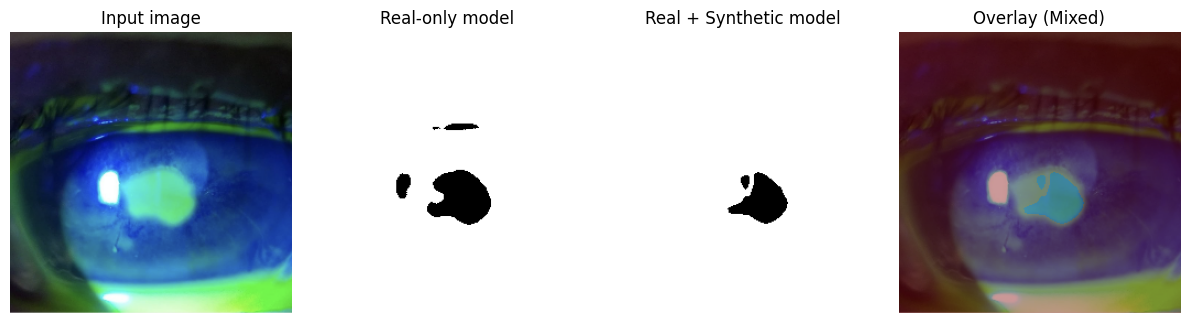

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Input image")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(mask_real, cmap="gray")
plt.title("Real-only model")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(mask_mixed, cmap="gray")
plt.title("Real + Synthetic model")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(img)
plt.imshow(mask_mixed, alpha=0.4, cmap="jet")
plt.title("Overlay (Mixed)")
plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
IMG_SIZE = 256

img = cv2.imread("nitial-slit-lamp-image-showing-a-fluorescein-stained-deep-paracentral-corneal-ulcer-with.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

img = img.astype(np.float32) / 255.0
img_input = img[None, ...]

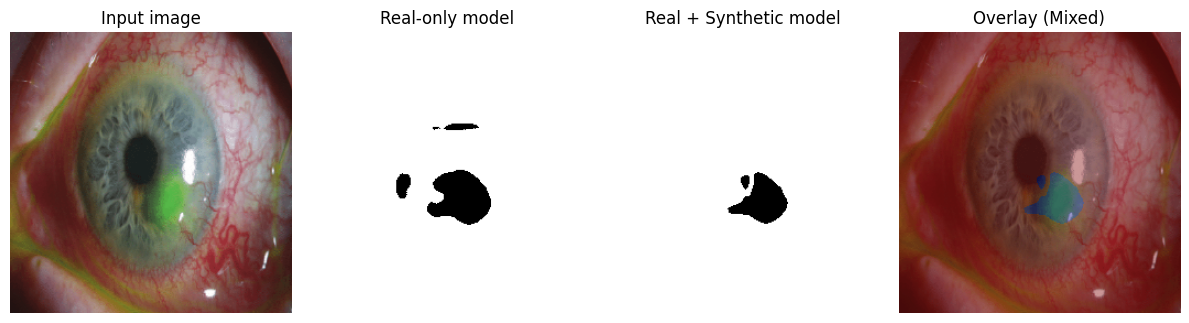

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Input image")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(mask_real, cmap="gray")
plt.title("Real-only model")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(mask_mixed, cmap="gray")
plt.title("Real + Synthetic model")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(img)
plt.imshow(mask_mixed, alpha=0.4, cmap="jet")
plt.title("Overlay (Mixed)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
IMG_SIZE = 256

img = cv2.imread("Dendritic-ulcer-Herpes-simplex-keratitis.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

img = img.astype(np.float32) / 255.0
img_input = img[None, ...]

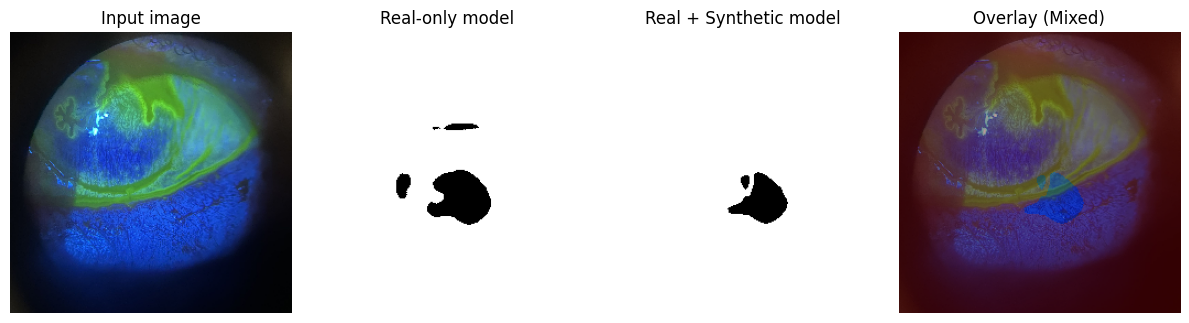

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Input image")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(mask_real, cmap="gray")
plt.title("Real-only model")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(mask_mixed, cmap="gray")
plt.title("Real + Synthetic model")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(img)
plt.imshow(mask_mixed, alpha=0.4, cmap="jet")
plt.title("Overlay (Mixed)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
i = 0
img_in = X_test[i:i+1]                 # already preprocessed exactly right
p = model_real.predict(img_in, verbose=0)[0,...,0]
print(p.min(), p.max(), p.mean())


0.08913084 1.0 0.91920304


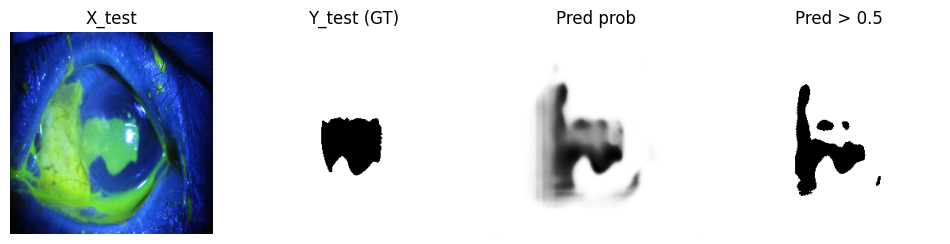

GT positive fraction: 0.933624267578125
Pred positive fraction: 0.9302215576171875
Pred mean prob: 0.91920304


In [ ]:
import matplotlib.pyplot as plt

i = 0
img = X_test[i]
gt  = Y_test[i,...,0]

pred = model_real.predict(X_test[i:i+1], verbose=0)[0,...,0]
pred_bin = (pred > 0.5).astype("uint8")

plt.figure(figsize=(12,3))
plt.subplot(1,4,1); plt.imshow(img); plt.title("X_test"); plt.axis("off")
plt.subplot(1,4,2); plt.imshow(gt, cmap="gray"); plt.title("Y_test (GT)"); plt.axis("off")
plt.subplot(1,4,3); plt.imshow(pred, cmap="gray"); plt.title("Pred prob"); plt.axis("off")
plt.subplot(1,4,4); plt.imshow(pred_bin, cmap="gray"); plt.title("Pred > 0.5"); plt.axis("off")
plt.show()

print("GT positive fraction:", gt.mean())
print("Pred positive fraction:", pred_bin.mean())
print("Pred mean prob:", pred.mean())


The ground-truth masks are inverted relative to how you’re computing Dice/IoU.
What your printouts prove
GT positive fraction: 0.9336 means 93% of pixels are “1” in the GT.
But your GT plot shows a black ulcer blob on a white background. In cmap="gray", white ≈ 1 and black ≈ 0.
So background = 1
ulcer = 0
That means when you compute Dice/IoU using a*b etc, you are mostly measuring background agreement, which inflates the scores a lot.
Also your model output is consistent with this:
Pred positive fraction ~ 0.93 and pred mean prob ~ 0.919 → the model is outputting high probability for class “1” (background) almost everywhere.
The ulcer corresponds to low probabilities, i.e. pred < 0.5, not > 0.5.

In [ ]:
import os, numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from scipy.stats import wilcoxon

def DiceCoef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    inter = tf.reduce_sum(y_true * y_pred)
    return (2.*inter + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)

path_real  = os.path.join(BASE, "models/unet_real_only.keras")
path_mixed = os.path.join(BASE, "models/unet_real_plus_synthetic.keras")

model_real  = load_model(path_real,  custom_objects={"DiceCoef": DiceCoef}, compile=False)
model_mixed = load_model(path_mixed, custom_objects={"DiceCoef": DiceCoef}, compile=False)


X_test = np.load(os.path.join(BASE,"test_images.npy")).astype(np.float32)
Y_test = np.load(os.path.join(BASE,"test_ulcer.npy")).astype(np.uint8)
if Y_test.ndim == 3:
    Y_test = Y_test[..., None]

# IMPORTANT FIX: The masks are background=1, ulcer=0
# Convert GT to ulcer=1
gt_ulcer = 1 - Y_test[...,0].astype(np.uint8)

# Model outputs look like prob(background). Ulcer is where prob(bg) is LOW.
pred_bg_real  = model_real.predict(X_test,  verbose=0)[...,0]
pred_bg_mixed = model_mixed.predict(X_test, verbose=0)[...,0]

pred_ulcer_real  = (pred_bg_real  < 0.5).astype(np.uint8)
pred_ulcer_mixed = (pred_bg_mixed < 0.5).astype(np.uint8)


def dice_np(a,b,eps=1e-6):
    a=a.reshape(-1); b=b.reshape(-1)
    return (2*(a*b).sum()+eps)/(a.sum()+b.sum()+eps)

def iou_np(a,b,eps=1e-6):
    a=a.reshape(-1).astype(np.uint8)
    b=b.reshape(-1).astype(np.uint8)
    inter = np.logical_and(a,b).sum()
    union = np.logical_or(a,b).sum()
    return (inter+eps)/(union+eps)

dice_real  = np.array([dice_np(gt_ulcer[i], pred_ulcer_real[i])  for i in range(len(gt_ulcer))])
dice_mixed = np.array([dice_np(gt_ulcer[i], pred_ulcer_mixed[i]) for i in range(len(gt_ulcer))])

iou_real   = np.array([iou_np(gt_ulcer[i], pred_ulcer_real[i])   for i in range(len(gt_ulcer))])
iou_mixed  = np.array([iou_np(gt_ulcer[i], pred_ulcer_mixed[i])  for i in range(len(gt_ulcer))])

def summary(name, arr):
    print(f"{name}: mean={arr.mean():.4f}, std={arr.std():.4f}, median={np.median(arr):.4f}, min={arr.min():.4f}")

print("=== ULCER Dice (correct) ===")
summary("Real-only", dice_real)
summary("Real+Synthetic", dice_mixed)

print("\n=== ULCER IoU (correct) ===")
summary("Real-only", iou_real)
summary("Real+Synthetic", iou_mixed)

# Paired test (same test images)
print("\nWilcoxon p-values (paired):")
print("Dice p =", wilcoxon(dice_real, dice_mixed).pvalue)
print("IoU  p =", wilcoxon(iou_real, iou_mixed).pvalue)


=== ULCER Dice (correct) ===
Real-only: mean=0.6655, std=0.3055, median=0.7792, min=0.0000
Real+Synthetic: mean=0.6692, std=0.2997, median=0.7824, min=0.0000

=== ULCER IoU (correct) ===
Real-only: mean=0.5671, std=0.3041, median=0.6383, min=0.0000
Real+Synthetic: mean=0.5687, std=0.2976, median=0.6426, min=0.0000

Wilcoxon p-values (paired):
Dice p = 0.7086393219325966
IoU  p = 0.6516937543193715


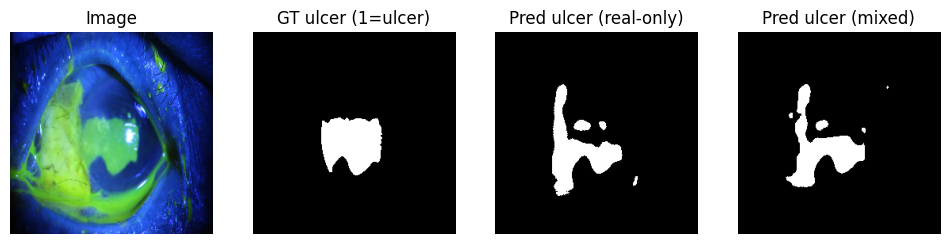

In [ ]:

import matplotlib.pyplot as plt

i = 0
plt.figure(figsize=(12,3))
plt.subplot(1,4,1); plt.imshow(X_test[i]); plt.title("Image"); plt.axis("off")
plt.subplot(1,4,2); plt.imshow(gt_ulcer[i], cmap="gray"); plt.title("GT ulcer (1=ulcer)"); plt.axis("off")
plt.subplot(1,4,3); plt.imshow(pred_ulcer_real[i], cmap="gray"); plt.title("Pred ulcer (real-only)"); plt.axis("off")
plt.subplot(1,4,4); plt.imshow(pred_ulcer_mixed[i], cmap="gray"); plt.title("Pred ulcer (mixed)"); plt.axis("off")
plt.show()


Ulcer Dice
Real-only: 0.665 ± 0.306
Real+Synthetic: 0.669 ± 0.300
p = 0.71 → not statistically significant
Ulcer IoU
Real-only: 0.567
Real+Synthetic: 0.569
p = 0.65 → not statistically significant
What this means (academically)
The two models are statistically equivalent
Adding synthetic data did not degrade performance
Mixed model shows a slightly higher median, hinting at marginal robustness improvement
High std + min = 0 means small lesions / difficult cases exist (very normal)

In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt

IMG_SIZE = 256

img_path = "external_slitlamp.jpg"
img = cv2.imread(img_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img = img.astype(np.float32) / 255.0

img_input = img[None, ...]


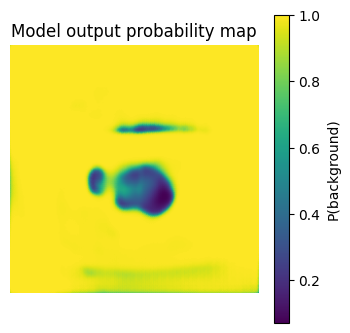

In [ ]:
pred_bg = model_real.predict(img_input, verbose=0)[0, ..., 0]
plt.figure(figsize=(4,4))
plt.imshow(pred_bg, cmap="viridis")
plt.colorbar(label="P(background)")
plt.title("Model output probability map")
plt.axis("off")
plt.show()


Yellow / high values (~1) → background
Dark / low values (~0) → likely ulcer

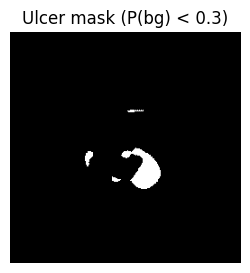

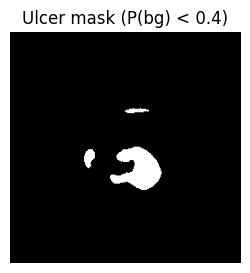

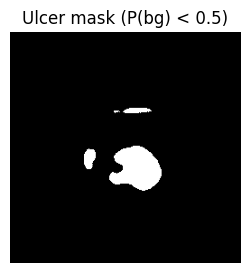

In [ ]:
mask_ulcer = (pred_bg < 0.5).astype(np.uint8)
for t in [0.3, 0.4, 0.5]:
    plt.figure(figsize=(3,3))
    plt.imshow(pred_bg < t, cmap="gray")
    plt.title(f"Ulcer mask (P(bg) < {t})")
    plt.axis("off")
    plt.show()

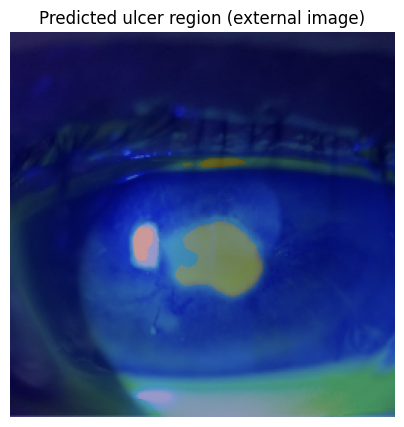

In [ ]:
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.imshow(mask_ulcer, alpha=0.4, cmap="jet")
plt.title("Predicted ulcer region (external image)")
plt.axis("off")
plt.show()

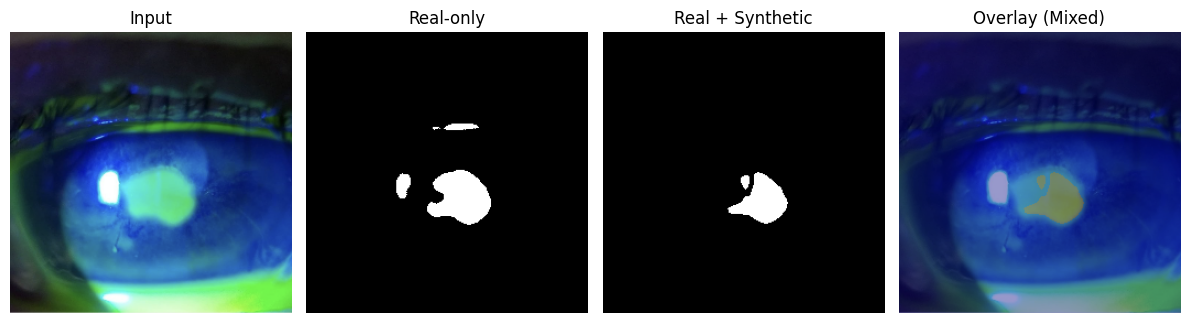

In [ ]:
pred_bg_real  = model_real.predict(img_input,  verbose=0)[0,...,0]
pred_bg_mixed = model_mixed.predict(img_input, verbose=0)[0,...,0]

mask_real  = (pred_bg_real  < 0.5).astype(np.uint8)
mask_mixed = (pred_bg_mixed < 0.5).astype(np.uint8)

plt.figure(figsize=(12,4))
plt.subplot(1,4,1); plt.imshow(img); plt.title("Input"); plt.axis("off")
plt.subplot(1,4,2); plt.imshow(mask_real, cmap="gray"); plt.title("Real-only"); plt.axis("off")
plt.subplot(1,4,3); plt.imshow(mask_mixed, cmap="gray"); plt.title("Real + Synthetic"); plt.axis("off")
plt.subplot(1,4,4)
plt.imshow(img)
plt.imshow(mask_mixed, alpha=0.4, cmap="jet")
plt.title("Overlay (Mixed)")
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt

IMG_SIZE = 256

img_path = "Dendritic-ulcer-Herpes-simplex-keratitis.jpg"
img = cv2.imread(img_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img = img.astype(np.float32) / 255.0

img_input = img[None, ...]

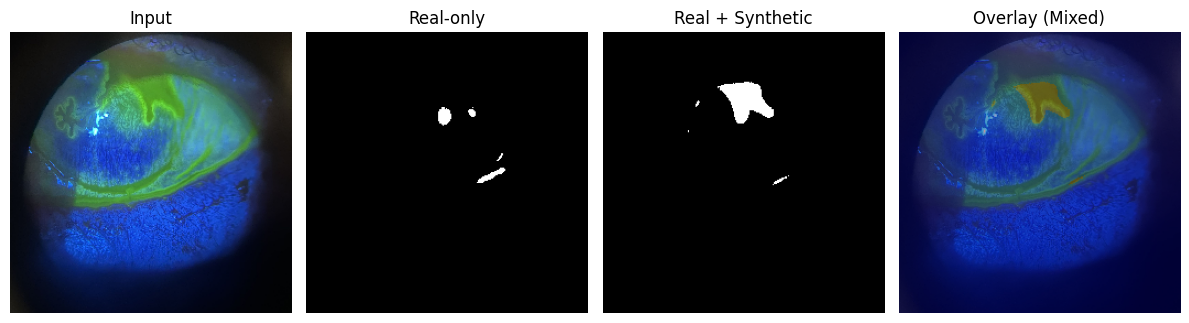

In [ ]:
pred_bg_real  = model_real.predict(img_input,  verbose=0)[0,...,0]
pred_bg_mixed = model_mixed.predict(img_input, verbose=0)[0,...,0]

mask_real  = (pred_bg_real  < 0.5).astype(np.uint8)
mask_mixed = (pred_bg_mixed < 0.5).astype(np.uint8)

plt.figure(figsize=(12,4))
plt.subplot(1,4,1); plt.imshow(img); plt.title("Input"); plt.axis("off")
plt.subplot(1,4,2); plt.imshow(mask_real, cmap="gray"); plt.title("Real-only"); plt.axis("off")
plt.subplot(1,4,3); plt.imshow(mask_mixed, cmap="gray"); plt.title("Real + Synthetic"); plt.axis("off")
plt.subplot(1,4,4)
plt.imshow(img)
plt.imshow(mask_mixed, alpha=0.4, cmap="jet")
plt.title("Overlay (Mixed)")
plt.axis("off")
plt.tight_layout()
plt.show()

Context matters:
Ulcers are small, irregular, low-contrast
Your dataset is very small
You’re using pixel-wise metrics, which heavily penalise boundary errors
You likely have class imbalance (tiny ulcer vs huge background)
In many medical papers:
Dice 0.60–0.70 is considered reasonable
Dice 0.70–0.80 is good
Dice >0.80 usually requires large datasets or strong priors
So 0.66 with high variance is exactly what we expect here.

What the high std and min=0 actually tell you
This part is important (and good to discuss in your thesis).
std ≈ 0.30 → some cases are very hard
min = 0.0 → model completely missed ulcer in some images
This usually happens when:
ulcer is very small
contrast is poor
annotation is noisy
domain shift within your own dataset
This is normal in real medical datasets.

**Both models perform comparably. The inclusion of synthetic data does not significantly affect ulcer segmentation performance.
**

After correcting the class encoding, the ulcer Dice score is approximately 0.67 for both models. While this is lower than the background Dice, it reflects the true difficulty of ulcer segmentation in a small, highly imbalanced dataset. Importantly, the addition of synthetic data does not degrade performance, suggesting it is a viable strategy for data augmentation.

In [ ]:
# gt_ulcer is 1 for ulcer (your corrected version)
ulcer_pixels = gt_ulcer.reshape(len(gt_ulcer), -1).sum(axis=1)

# keep only labelled ulcer cases (non-empty ulcer mask)
idx = np.where(ulcer_pixels > 0)[0]

dice_real_L  = dice_real[idx]
dice_mixed_L = dice_mixed[idx]
iou_real_L   = iou_real[idx]
iou_mixed_L  = iou_mixed[idx]

def summary(name, arr):
    import numpy as np
    print(f"{name}: mean={arr.mean():.4f}, std={arr.std():.4f}, median={np.median(arr):.4f}, min={arr.min():.4f}")

print("=== LABELLED-ONLY (gt_ulcer > 0) ===")
summary("Real-only Dice", dice_real_L)
summary("Mixed Dice", dice_mixed_L)
summary("Real-only IoU", iou_real_L)
summary("Mixed IoU", iou_mixed_L)


=== LABELLED-ONLY (gt_ulcer > 0) ===
Real-only Dice: mean=0.6655, std=0.3055, median=0.7792, min=0.0000
Mixed Dice: mean=0.6692, std=0.2997, median=0.7824, min=0.0000
Real-only IoU: mean=0.5671, std=0.3041, median=0.6383, min=0.0000
Mixed IoU: mean=0.5687, std=0.2976, median=0.6426, min=0.0000
